# 🌸 Iris Flower Classification
### CodeAlpha Machine Learning Internship — Task 1
**Intern:** Raj Chakrawarti | **ID:** CA/DF1/68634

---
## 📌 Objective
Build a full ML pipeline to classify Iris flowers into 3 species:
- **Setosa**
- **Versicolor**
- **Virginica**


using features: Sepal Length, Sepal Width, Petal Length, Petal Width

## 📦 Step 1: Import Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - Evaluation
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load & Explore Dataset

In [2]:
# Load Iris Dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print('📊 Dataset Shape:', df.shape)
print('\n🔍 First 5 rows:')
df.head()

📊 Dataset Shape: (150, 6)

🔍 First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
# Basic Info
print('📋 Dataset Info:')
print(df.info())
print('\n📈 Statistical Summary:')
df.describe()

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

📈 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check for missing values
print('🔎 Missing Values:')
print(df.isnull().sum())

# Class Distribution
print('\n🌸 Class Distribution:')
print(df['species_name'].value_counts())

🔎 Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

🌸 Class Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


## 📊 Step 3: Exploratory Data Analysis (EDA)

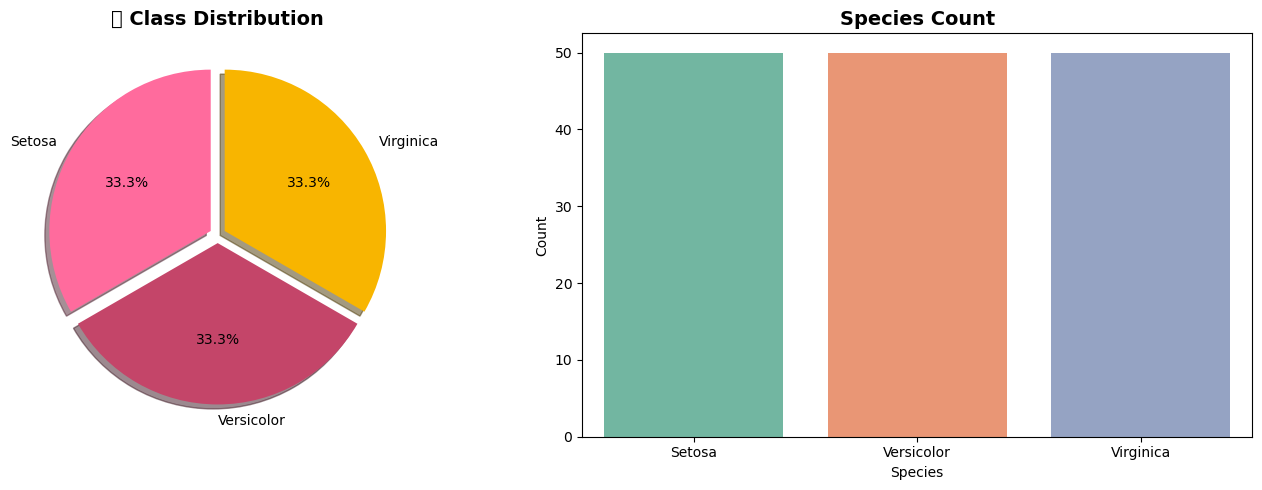

In [5]:
# 1. Class Distribution - Pie Chart
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
colors = ['#FF6B9D', '#C44569', '#F8B500']
df['species_name'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=colors, startangle=90,
    explode=(0.05, 0.05, 0.05), shadow=True
)
plt.title('🌸 Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')

# 2. Count Plot
plt.subplot(1, 2, 2)
sns.countplot(x='species_name', data=df, palette='Set2')
plt.title('Species Count', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

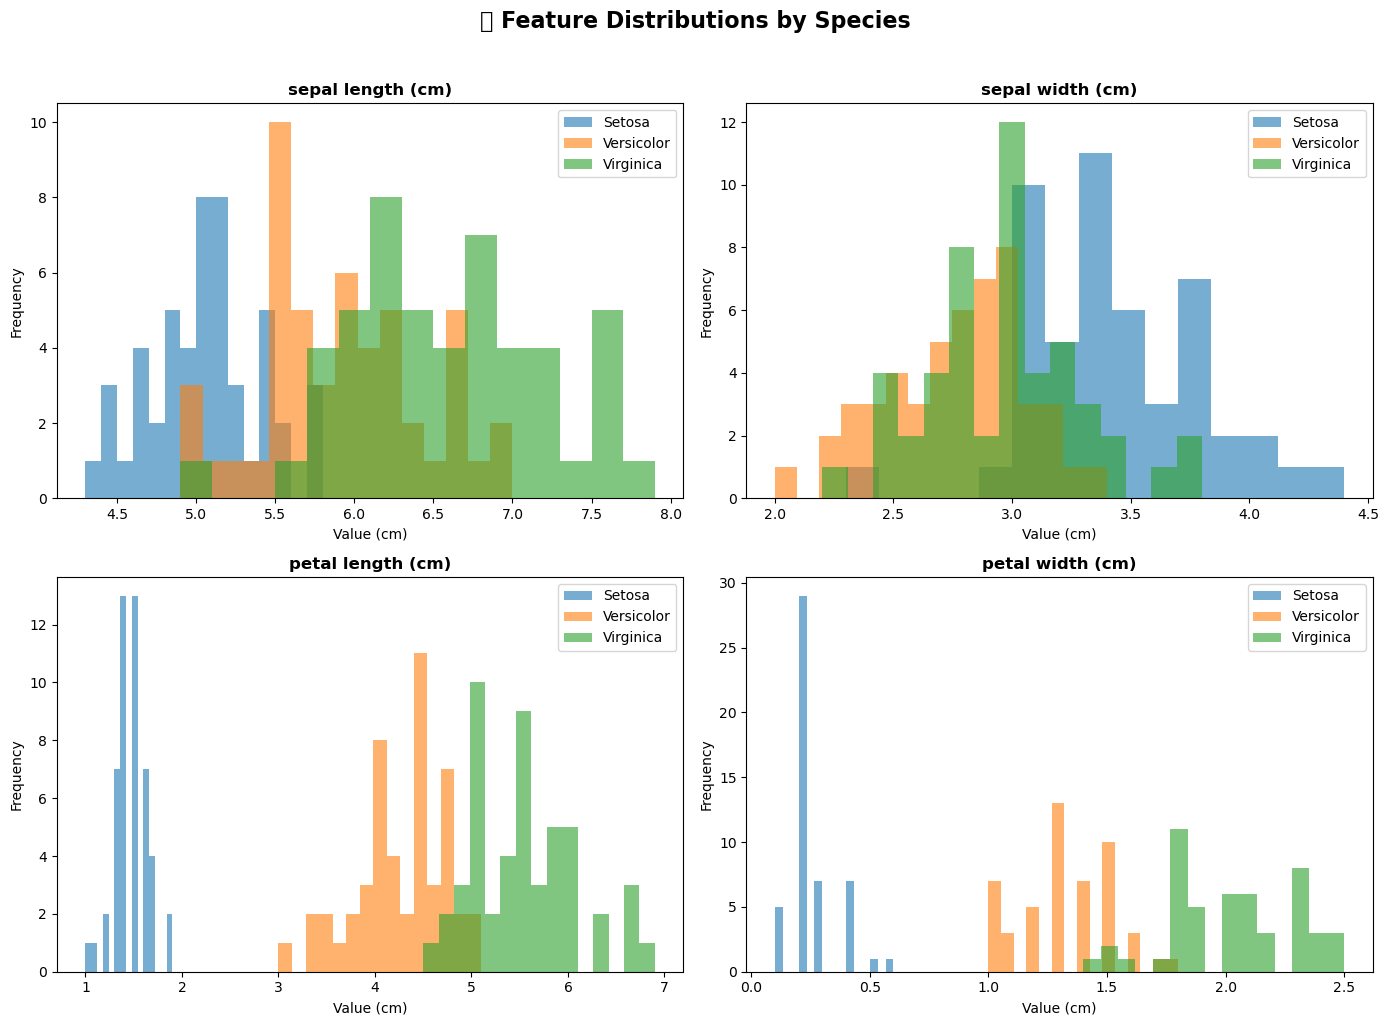

In [6]:
# Feature Distributions - Histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names
colors_list = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors_list)):
    for species, grp in df.groupby('species_name'):
        ax.hist(grp[feature], bins=15, alpha=0.6, label=species)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('📊 Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

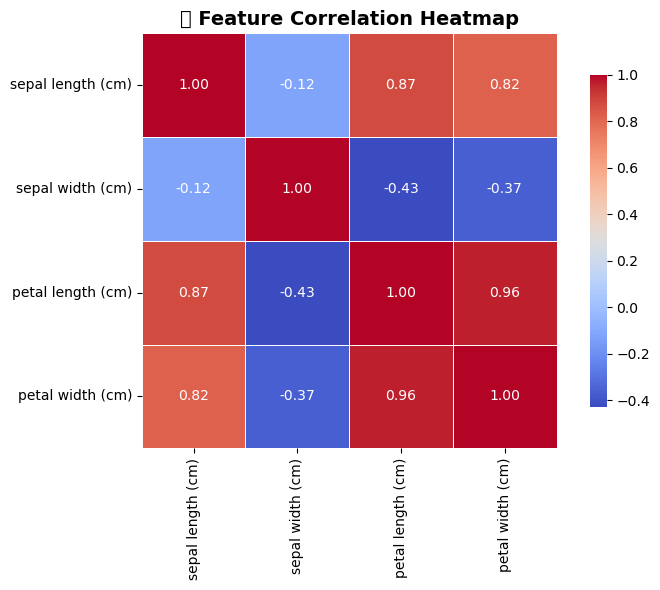

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

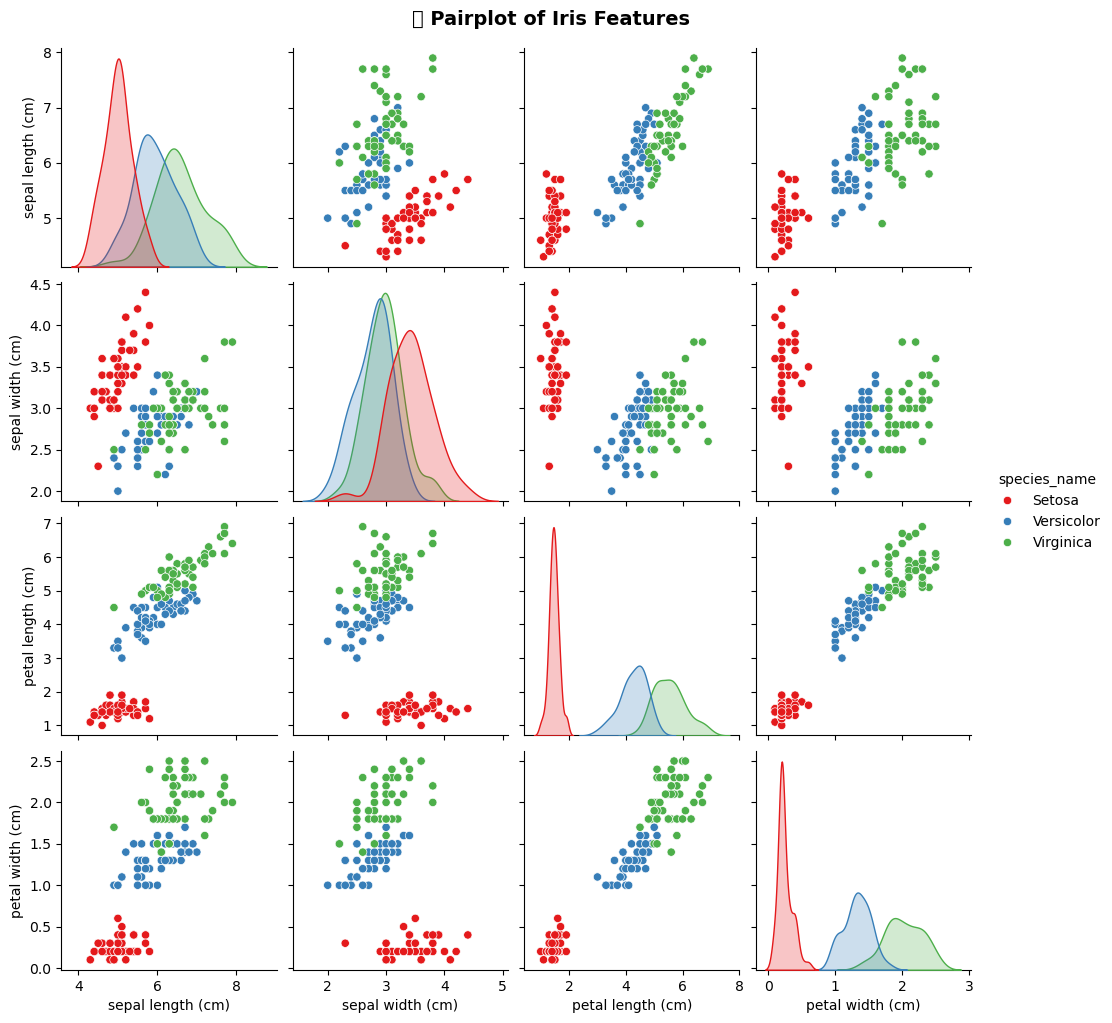

In [8]:
# Pairplot
sns.pairplot(df, hue='species_name', palette='Set1',
             vars=iris.feature_names, diag_kind='kde')
plt.suptitle('🌸 Pairplot of Iris Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

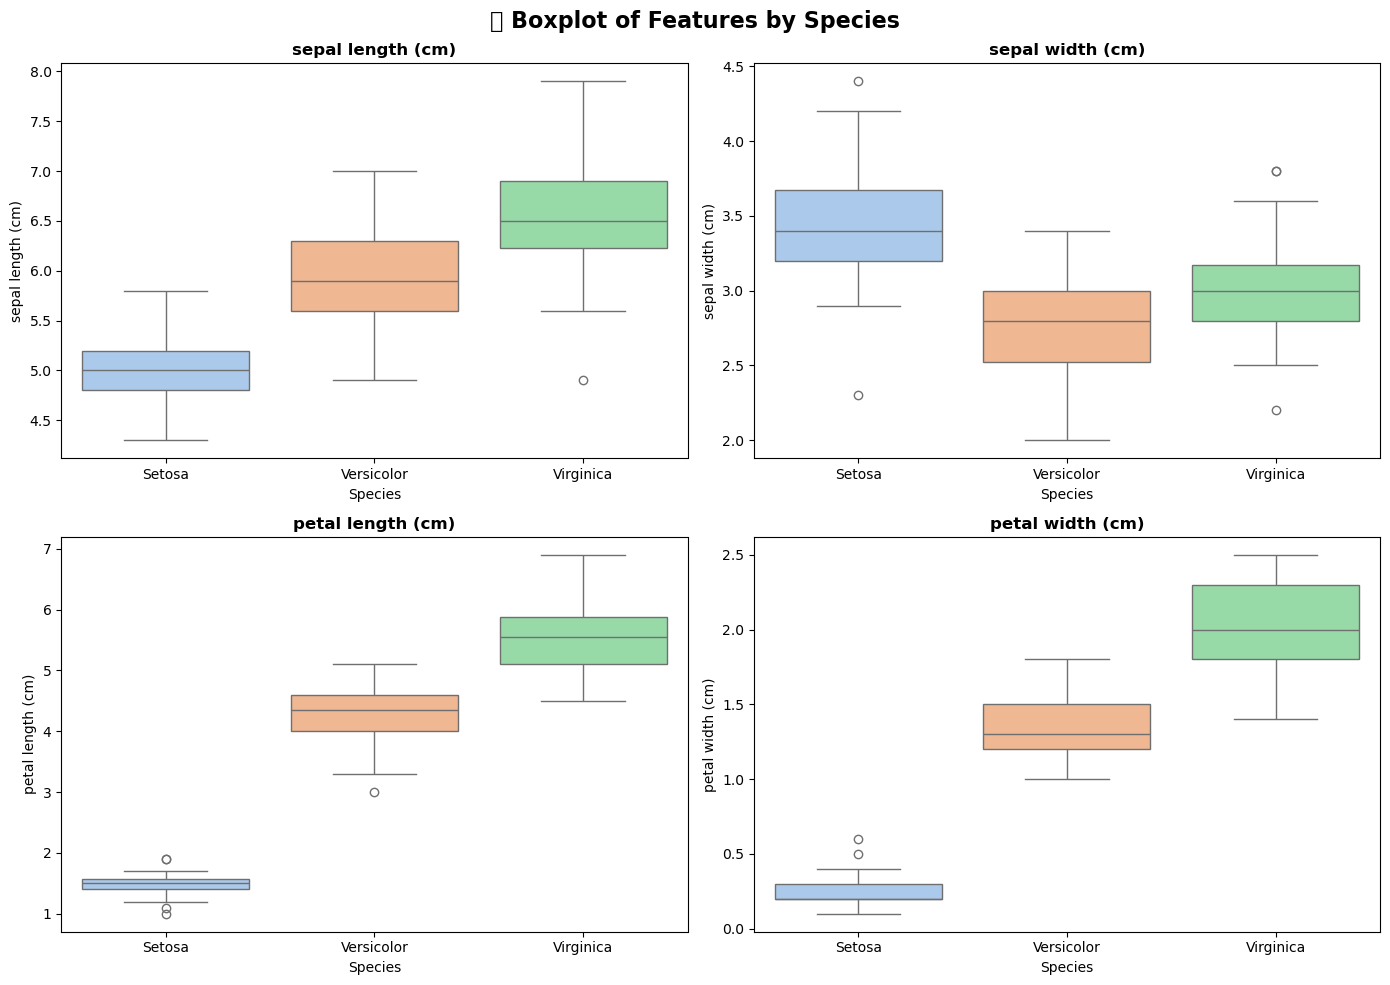

In [9]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(x='species_name', y=feature, data=df,
                palette='pastel', ax=ax)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Species')

plt.suptitle('📦 Boxplot of Features by Species', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Data Preprocessing

In [10]:
# Features and Target
X = df[iris.feature_names]
y = df['species']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Training samples : {X_train.shape[0]}')
print(f'✅ Testing samples  : {X_test.shape[0]}')
print(f'✅ Features         : {X_train.shape[1]}')

✅ Training samples : 120
✅ Testing samples  : 30
✅ Features         : 4


## 🤖 Step 5: Model Training & Comparison

In [11]:
# Define Models
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=200),
    'Decision Tree'           : DecisionTreeClassifier(random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                     : SVC(kernel='rbf', probability=True, random_state=42),
    'KNN'                     : KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting'       : GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'Test Accuracy'  : round(acc * 100, 2),
        'CV Mean'        : round(cv_scores.mean() * 100, 2),
        'CV Std'         : round(cv_scores.std() * 100, 2)
    }
    print(f'✅ {name:25s} | Test Acc: {acc*100:.2f}% | CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

results_df = pd.DataFrame(results).T.sort_values('Test Accuracy', ascending=False)
print('\n🏆 Model Comparison:')
results_df

✅ Logistic Regression       | Test Acc: 93.33% | CV: 95.83% ± 2.64%
✅ Decision Tree             | Test Acc: 93.33% | CV: 94.17% ± 2.04%
✅ Random Forest             | Test Acc: 90.00% | CV: 95.00% ± 1.67%
✅ SVM                       | Test Acc: 96.67% | CV: 96.67% ± 3.12%
✅ KNN                       | Test Acc: 93.33% | CV: 96.67% ± 3.12%
✅ Gradient Boosting         | Test Acc: 96.67% | CV: 95.83% ± 2.64%

🏆 Model Comparison:


,Test Accuracy,CV Mean,CV Std
Gradient Boosting,96.67,95.83,2.64
SVM,96.67,96.67,3.12
Decision Tree,93.33,94.17,2.04
Logistic Regression,93.33,95.83,2.64
KNN,93.33,96.67,3.12
Random Forest,90.00,95.00,1.67


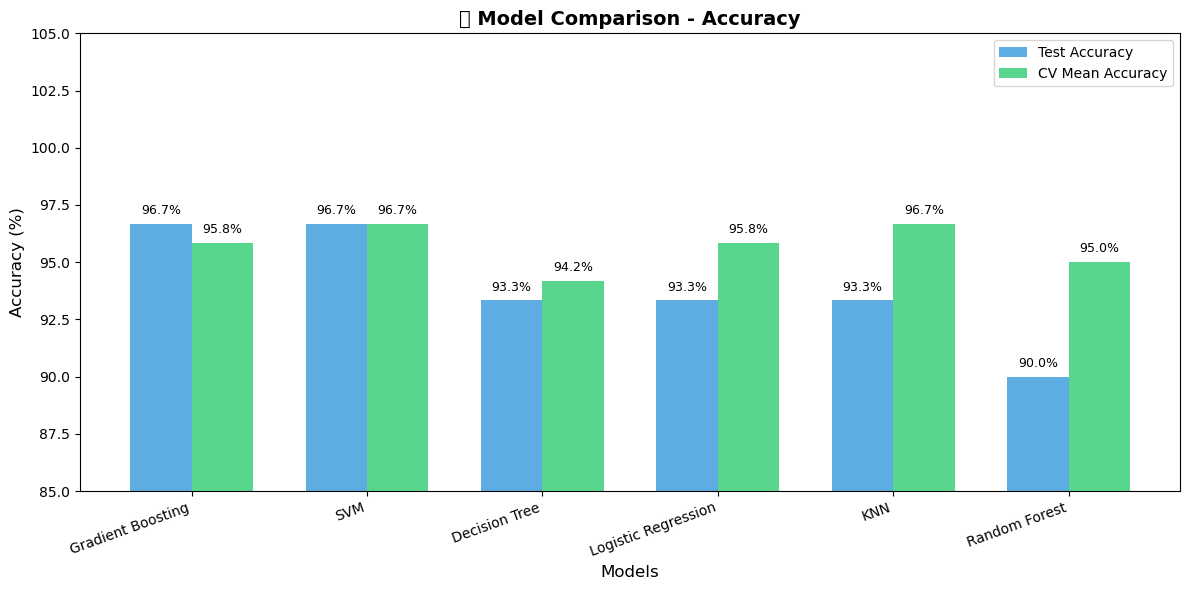


🏆 Best Model: Gradient Boosting with 96.67% accuracy!


In [12]:
# Model Comparison Bar Chart
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

bars1 = plt.bar(x - width/2, results_df['Test Accuracy'], width,
                label='Test Accuracy', color='#3498db', alpha=0.8)
bars2 = plt.bar(x + width/2, results_df['CV Mean'], width,
                label='CV Mean Accuracy', color='#2ecc71', alpha=0.8)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('🤖 Model Comparison - Accuracy', fontsize=14, fontweight='bold')
plt.xticks(x, results_df.index, rotation=20, ha='right')
plt.legend()
plt.ylim(85, 105)

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f'\n🏆 Best Model: {best_model_name} with {results_df["Test Accuracy"][0]}% accuracy!')

## 🔧 Step 6: Hyperparameter Tuning (Best Model)

In [13]:
# Hyperparameter tuning for Random Forest
print('🔧 Tuning Random Forest...')

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f'\n✅ Best Parameters : {grid_search.best_params_}')
print(f'✅ Best CV Score   : {grid_search.best_score_*100:.2f}%')

best_model = grid_search.best_estimator_

🔧 Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Parameters : {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV Score   : 95.83%


## 📈 Step 7: Final Model Evaluation

In [14]:
# Final Predictions
y_pred_final = best_model.predict(X_test_scaled)
final_acc    = accuracy_score(y_test, y_pred_final)

print('=' * 50)
print('📊 FINAL MODEL EVALUATION REPORT')
print('=' * 50)
print(f'\n🎯 Final Test Accuracy: {final_acc*100:.2f}%')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_final,
      target_names=['Setosa', 'Versicolor', 'Virginica']))

📊 FINAL MODEL EVALUATION REPORT

🎯 Final Test Accuracy: 96.67%

📋 Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



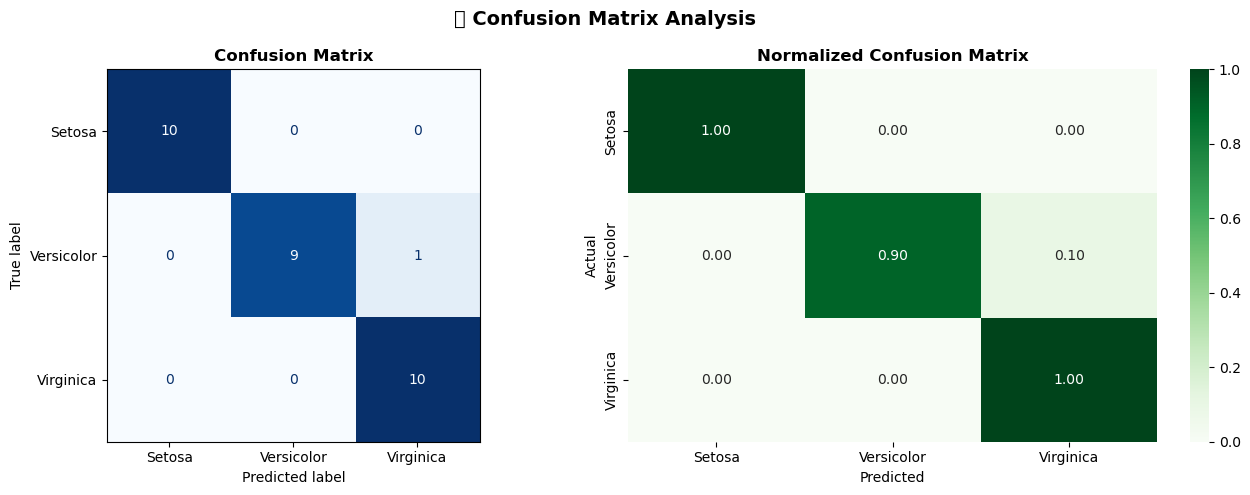

In [15]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Setosa', 'Versicolor', 'Virginica'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Normalized Confusion Matrix
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'], ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('🎯 Confusion Matrix Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Step 8: Feature Importance

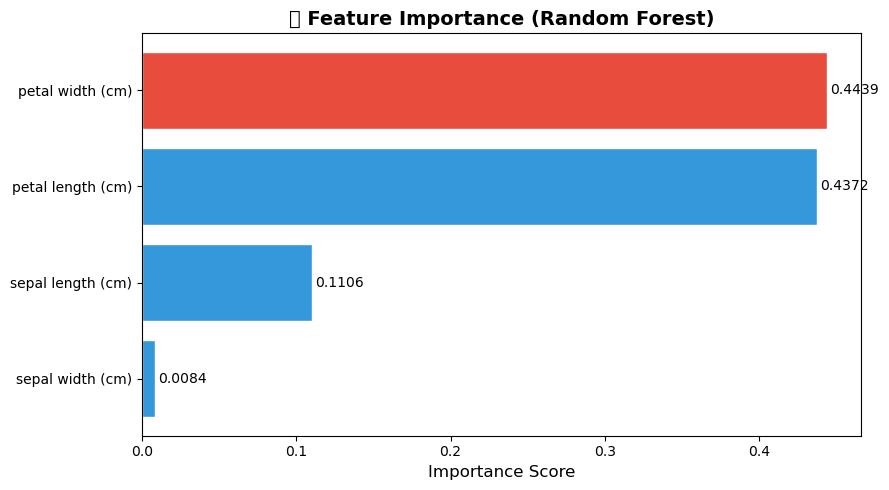


🏆 Most Important Feature: petal width (cm)


In [16]:
# Feature Importance Plot
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if i == feat_df['Importance'].idxmax() else '#3498db'
          for i in feat_df.index]
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')

for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.xlabel('Importance Score', fontsize=12)
plt.title('🔍 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_feature = feat_df.iloc[-1]['Feature']
print(f'\n🏆 Most Important Feature: {top_feature}')

## 🔮 Step 9: Predict on New Data

In [17]:
# Predict on Custom Input
species_map = {0: '🌸 Setosa', 1: '🌺 Versicolor', 2: '🌹 Virginica'}

new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],   # Expected: Setosa
    [6.0, 2.9, 4.5, 1.5],   # Expected: Versicolor
    [6.7, 3.1, 5.6, 2.4],   # Expected: Virginica
])

new_scaled   = scaler.transform(new_samples)
predictions  = best_model.predict(new_scaled)
probabilities = best_model.predict_proba(new_scaled)

print('🔮 Predictions on New Samples:\n')
print(f'{"Sample":<10} {"Sepal L":<10} {"Sepal W":<10} {"Petal L":<10} {"Petal W":<10} {"Prediction":<20} {"Confidence"}')
print('-' * 80)
for i, (sample, pred, prob) in enumerate(zip(new_samples, predictions, probabilities)):
    conf = prob.max() * 100
    print(f'{i+1:<10} {sample[0]:<10} {sample[1]:<10} {sample[2]:<10} {sample[3]:<10} {species_map[pred]:<20} {conf:.2f}%')

🔮 Predictions on New Samples:

Sample     Sepal L    Sepal W    Petal L    Petal W    Prediction           Confidence
--------------------------------------------------------------------------------
1          5.1        3.5        1.4        0.2        🌸 Setosa             100.00%
2          6.0        2.9        4.5        1.5        🌺 Versicolor         97.46%
3          6.7        3.1        5.6        2.4        🌹 Virginica          100.00%


## 📝 Step 10: Summary & Conclusion

In [18]:
print('=' * 60)
print('📊 IRIS FLOWER CLASSIFICATION — FINAL SUMMARY')
print('=' * 60)
print()
print('📁 Dataset    : Iris Dataset (150 samples, 4 features, 3 classes)')
print('🔀 Split      : 80% Train | 20% Test (Stratified)')
print('⚙️  Scaling    : StandardScaler')
print()
print('🤖 Models Trained:')
for model_name, res in results.items():
    print(f'   • {model_name:25s} → {res["Test Accuracy"]}%')
print()
print(f'🏆 Best Model  : Random Forest (Tuned)')
print(f'🎯 Final Accuracy : {final_acc*100:.2f}%')
print()
print('🔍 Key Findings:')
print('   • Petal Length & Petal Width are most discriminative features')
print('   • Setosa is perfectly separable from others')
print('   • Versicolor & Virginica have some overlap')
print('   • Random Forest gives best performance overall')
print()
print('👨‍💻 Author : Raj Chakrawarti | CodeAlpha Internship | Task 1')
print('=' * 60)

📊 IRIS FLOWER CLASSIFICATION — FINAL SUMMARY

📁 Dataset    : Iris Dataset (150 samples, 4 features, 3 classes)
🔀 Split      : 80% Train | 20% Test (Stratified)
⚙️  Scaling    : StandardScaler

🤖 Models Trained:
   • Logistic Regression       → 93.33%
   • Decision Tree             → 93.33%
   • Random Forest             → 90.0%
   • SVM                       → 96.67%
   • KNN                       → 93.33%
   • Gradient Boosting         → 96.67%

🏆 Best Model  : Random Forest (Tuned)
🎯 Final Accuracy : 96.67%

🔍 Key Findings:
   • Petal Length & Petal Width are most discriminative features
   • Setosa is perfectly separable from others
   • Versicolor & Virginica have some overlap
   • Random Forest gives best performance overall

👨‍💻 Author : Raj Chakrawarti | CodeAlpha Internship | Task 1
